# DANSy Analysis of fusion genes in the Cancer Cell Line Encyclopedia

Here to expand upon the fusion analysis done on The Cancer Genome Atlas (TCGA), we will now explore fusions within the Cancer Cell Line Encyclopedia (CCLE). Using this analysis we will see how the fusions impact cell survival by making cell lines with the fusion more dependent on the partner genes of the fusions.

In [ ]:
import dansy
import numpy as np
import pandas as pd
import fusionClasses as fc
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from collections import Counter

In [2]:
# Now let's set up a handful of matplotlib default values
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.01
plt.rcParams['lines.markeredgewidth'] = 0.01
plt.rcParams['figure.dpi'] = 300


In [3]:
# Importing several useful files.
gene_conv = pd.read_csv('ENSEMBL_Gene_Conversion.csv')
gene_conv = gene_conv.filter(['Gene stable ID', 'Gene name'], axis = 1).drop_duplicates()
conv_dict = dict(zip(gene_conv['Gene name'], gene_conv['Gene stable ID']))

# The CCLE information
ccle_fusions = pd.read_csv('CCLE_OmicsFusionFilteredSupplementary.csv', index_col=0)
ccle_model_info = pd.read_csv('CCLE_Model.csv')

In [4]:
def fix_ensembl(row, gene_pos, cnv = conv_dict):
    ensembl_name = f'gene{gene_pos}_ensembl'
    symbol_name =f'gene{gene_pos}_symbol'
    val = row[ensembl_name]
    gene_name = row[symbol_name]
    if val == '':
        
        if gene_name in cnv.keys():
            new_val = cnv[gene_name]
        else:
            new_val = None
    elif val in cnv.values():
        new_val = val
    else: # Double-check any that are not the current ENSEMBL ID
        if gene_name in cnv.keys():
            new_val = cnv[gene_name]
        else:
            new_val = None
    
    return new_val

## Start of analysis

Here, we will take a small approach as what was done by [Gillani et al. ***Cancer Res*** 2021](https://doi.org/10.1158/0008-5472.CAN-21-0791), but slightly adjusted. I will determine the difference in dependency score for each fusion gene, but relative only to those lines from the same lineage.


In [5]:
# A little bit of pre-filtering to remove any of the out of frame fusions because predicting their domain architecture is not accurate
ccle_fusions = ccle_fusions[ccle_fusions['reading_frame'] == 'in-frame']

# Additionally removing low confidence fusions and any with FFPM value < 0.1 a general cutoff for fusion artifacts
ccle_fusions = ccle_fusions[ccle_fusions['confidence'] == 'high']
ccle_fusions = ccle_fusions[ccle_fusions['FFPM'] >= 0.1]

# Now let's create a new dataframe that has only relevant information for the time being that can then be passed on to create a fusion gene collection object.
dataOI = ccle_fusions.filter(['ModelID','CanonicalFusionName', 'gene1(ENS ID)', 'gene2(ENS ID)','strand1(gene/fusion)', 'strand2(gene/fusion)','breakpoint1', 'breakpoint2']).copy()
dataOI[['gene1_symbol','gene1_ensembl'] ]= dataOI['gene1(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI[['gene2_symbol','gene2_ensembl']] = dataOI['gene2(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI['gene1_symbol']=dataOI['gene1_symbol'].str.strip()
dataOI['gene2_symbol']=dataOI['gene2_symbol'].str.strip()
dataOI['gene1_ensembl']=dataOI['gene1_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['gene2_ensembl']=dataOI['gene2_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['strand1'] = dataOI['strand1(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI['strand2'] = dataOI['strand2(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI[['gene1_chr','gene1_pos']] = dataOI['breakpoint1'].str.split(':', n=1, expand=True)
dataOI[['gene2_chr','gene2_pos']] = dataOI['breakpoint2'].str.split(':', n=1, expand=True)
dataOI['gene1_pos']=dataOI['gene1_pos'].astype(int)
dataOI['gene2_pos']=dataOI['gene2_pos'].astype(int)


# Mapping missing gene ensembl names
dataOI['gene1_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 1) , axis=1)
dataOI['gene2_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 2) , axis=1)
dataOI.dropna(subset=['gene1_ensembl', 'gene2_ensembl'],inplace=True)

In [6]:
# Importing the dependency scores
dep_scores = pd.read_csv('CRISPRGeneEffect.csv')
dep_scores.rename(columns={'Unnamed: 0':'ModelID'}, inplace=True)

# Now let's just filter the columns to those from the fusion genes.
# Getting the fusion genes
allgenes = list(set(dataOI['gene1_symbol']).union(dataOI['gene2_symbol']))

# Now filtering the columns based on whether they were in a fusion
c = [g for g in dep_scores if g.split(' ')[0] in allgenes]
dep_scores = dep_scores.filter(['ModelID']+c, axis = 1)
colname2gene = {x.split(' ')[0]:x for x in dep_scores.columns}
del colname2gene['ModelID']
# now let's integrate the model lineage and names into the dependency scores
dep_analysis = ccle_model_info.filter(['ModelID','CellLineName','OncotreeLineage']).merge(dep_scores, left_on='ModelID',right_on = 'ModelID')
# Let's only keep lineages with >= 10 models
lineages2keep = [k for k,v in Counter(dep_analysis.OncotreeLineage).items() if v >= 10]

# Run through and get groups for the dependency score analysis and then use the BCR-ABL for the time being as a model of the larger framework
dep_analysis = dep_analysis[dep_analysis.OncotreeLineage.isin(lineages2keep)]
dep_analysis_grouped = dep_analysis.groupby('OncotreeLineage')

In [7]:
# Now let's grab the model IDs and filter the fusion data to only include models that have the CRISPR data as well.
crispr_lines = dep_analysis.ModelID.unique()
fusions4analysis = dataOI[dataOI.ModelID.isin(crispr_lines)]

In [8]:
# DANSy object of the full natural proteome
ref_df = dansy.import_proteome_files(ref_file_dir='data/Current_Human_Proteome',
                                       ref_file_suffix='2026_0324.csv')
proteome_net = dansy.dansy(ref=ref_df, n=15)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [9]:
# Now with all the pre-filtering done let's run the DANSy fusion analysis
mappings = {'h_gene':'gene1_ensembl', 't_gene':'gene2_ensembl', 'h_chr':'gene1_chr', 't_chr':'gene2_chr', 'h_strand':'strand1', 't_strand':'strand2', 'name':'CanonicalFusionName', 'h_pos':'gene1_pos', 't_pos':'gene2_pos'}
ccle_fc = fc.fusionCollection(fusions4analysis, mappings, add_cols=['ModelID', 'gene1_symbol','gene2_symbol'])
ccle_fc.perform_dansy_analysis(dansy_obj=proteome_net)
dansy_sum = ccle_fc.summarize_dansy_results()

100%|██████████| 1430/1430 [00:02<00:00, 568.33it/s]

There were 629 fusion domain architectures previously found in the proteome.


In [10]:
# Now we will take the DANSy results and group them 
dansy_sum['fusion_protein'] = dansy_sum['gene1_symbol'].str.cat(dansy_sum['gene2_symbol'], sep = '--')

# Group these results so that we can then check for how many lineages are represented in a single grouping
dansy_fusion_res = dansy_sum.dropna(subset='dansy_impact').groupby(['fusion_protein','dansy_impact','domain_architecture'])

multilineage_groups = []
# Check for potential multiple lineages:
for group in dansy_fusion_res.groups:
    x = dansy_fusion_res.get_group(group)
    if len(x) > 1:
        models = x.ModelID.unique()
        potential_lineages = ccle_model_info[ccle_model_info.ModelID.isin(models)].OncotreeLineage.unique()
        if len(potential_lineages) > 1:
            multilineage_groups.append(group)


In [11]:
def fusion_partner_dependencies_predefined_models(dep_df, fusion_models, genefusion, conv = colname2gene):
    
    withfusion = dep_df[dep_df.ModelID.isin(fusion_models)]
    withoutfusion = dep_df[~dep_df.ModelID.isin(fusion_models)]

    gene1, gene2 = genefusion.split('--')

    # Stats test
    g1p = stats.ttest_ind(withfusion[conv[gene1]], withoutfusion[conv[gene1]]).pvalue
    g2p = stats.ttest_ind(withfusion[conv[gene2]], withoutfusion[conv[gene2]]).pvalue

    # Calculating difference
    g1diff = withoutfusion[conv[gene1]].mean() - withfusion[conv[gene1]].mean()
    g2diff = withoutfusion[conv[gene2]].mean() - withfusion[conv[gene2]].mean()

    # Now place into a Series
    output = pd.Series([gene1, g1diff, g1p, gene2, g2diff, g2p], index = ['gene_1','gene_1_Difference','gene_1_p','gene_2','gene_2_Difference','gene_2_p'])

    return output

def check_fusion_columns(fusion, df:pd.DataFrame, conv= colname2gene):

    genes = fusion.split('--')
    conversion_possible = [g in conv for g in genes]

    if all(conversion_possible):
        colexist = [conv[g] in df.dropna(axis=1).columns for g in genes]
    else:
        colexist = [False]

    return all(colexist)


In [12]:
# Now getting the dependencies for each of the fusion groups
dep_res = []
for group in dansy_fusion_res.groups:
    x = dansy_fusion_res.get_group(group)
    models = x.ModelID.unique()
    potential_lineages = ccle_model_info[ccle_model_info.ModelID.isin(models)].OncotreeLineage.unique()
    for lineage in potential_lineages:
        lineage_dep = dep_analysis_grouped.get_group(lineage)
        if check_fusion_columns(group[0], lineage_dep):
            diff_dep_res = fusion_partner_dependencies_predefined_models(lineage_dep, models, group[0])
            diff_dep_res['Lineage'] = lineage
            diff_dep_res['N'] = len(set(models).intersection(lineage_dep.ModelID))
            temp = pd.Series(group, index = ['fusion_protein','dansy_impact','domain_architecture'])
            diff_dep_res = pd.concat([temp,diff_dep_res])
            dep_res.append(diff_dep_res)


### Trying an alternative approach for designating the fusion is "essential" or has a functional effect on cell viability when removed.

Here to mostly explore the statistical power of the fusion, I will be doing a KS-like test on randomly permutating the cell lines designated as having a fusion and which 2 genes are part of the fusion. This can give me a distribution of the mean difference in dependency scores can alleviate some of my concerns on the assumptions made with relying on a t-test with equal variance.

The steps go as follows:
1. Compute the mean differential dependency score difference for the fusion gene between cell lines with the fusion and those without.
2. Create 1000 permutations where the same number of cell lines as the fusion in question are designated as having a fusion.
3. For each permutation, randomly choose 2 genes with CRISPR dependency scores.
4. In each permutation calculate a mean differential dependency score difference.
5. Calculate a False Positive Rate
6. Correct for multiple comparisons with the BH method.

In [13]:
import random

In [14]:
# Defining the necessary functions.

def get_mdds(dep_df, fusion_models, genefusion, conv=colname2gene):
    
    withfusion = dep_df[dep_df.ModelID.isin(fusion_models)]
    withoutfusion = dep_df[~dep_df.ModelID.isin(fusion_models)]

    gene1, gene2 = genefusion.split('--')

    # Calculating difference
    g1diff = withoutfusion[conv[gene1]].mean() - withfusion[conv[gene1]].mean()
    g2diff = withoutfusion[conv[gene2]].mean() - withfusion[conv[gene2]].mean()

    mdds = np.mean([g1diff, g2diff])

    return mdds

def create_permutations(dep_df, genefusion, n_models, conv=colname2gene, iters = 1000):

    allmodels = sorted(dep_df.ModelID.unique())
    model_perms = [random.sample(allmodels, k = n_models) for i in range(iters)]
    temp_gene_perms = [random.choices(list(conv.keys()),k = 2) for i in range(iters)] #choices instead because want to account for any duplication events
    gene_perms = ['--'.join(i) for i in temp_gene_perms]
    
    # For the rare case when the gene fusion of interest is recreated
    if genefusion in gene_perms:
        new_fusion = '--'.join(random.choices(list(conv.keys()),k = 2))
        gene_perms[gene_perms == genefusion] = new_fusion

    return [(model_perms[i],gene_perms[i]) for i in range(iters)]

def get_background_dist(dep_df, genefusion,n_models, conv=colname2gene, iters = 1000):

    bckgrnd_perms = create_permutations(dep_df, genefusion, n_models, conv, iters)
    mdds_dist = []
    for model,fusion in bckgrnd_perms:
        mdds_dist.append(get_mdds(dep_df, model, fusion, conv=conv))
    
    return mdds_dist

def calc_fpr(x,dist):
    
    fp = sum([i >= x for i in dist])
    return fp/len(dist)



    


In [15]:
from tqdm import tqdm

In [16]:
random.seed(123)
dep_fpr_res = []
for group in tqdm(dansy_fusion_res.groups):
    x = dansy_fusion_res.get_group(group)
    genes = set(group[0].split('--'))

    models = x.ModelID.unique()
    potential_lineages = ccle_model_info[ccle_model_info.ModelID.isin(models)].OncotreeLineage.unique()
    for lineage in potential_lineages:
        lineage_dep = dep_analysis_grouped.get_group(lineage)
        if check_fusion_columns(group[0], lineage_dep):
            diff_dep_res = pd.Series()
            diff_dep_res['MDDS'] = get_mdds(lineage_dep, models, group[0])
            diff_dep_res['Lineage'] = lineage
            diff_dep_res['N'] = len(set(models).intersection(lineage_dep.ModelID))
            d = get_background_dist(lineage_dep, group[0],diff_dep_res['N'],iters=10)
            diff_dep_res['FPR'] = calc_fpr(diff_dep_res['MDDS'],d)
            temp = pd.Series(group, index = ['fusion_protein','dansy_impact','domain_architecture'])
            diff_dep_res = pd.concat([temp,diff_dep_res])
            dep_fpr_res.append(diff_dep_res)
            


100%|██████████| 2362/2362 [00:22<00:00, 106.49it/s]


In [17]:
dep_fpr_analysis = pd.DataFrame.from_records(dep_fpr_res)
dep_fpr_analysis.FPR = dep_fpr_analysis.FPR.apply(lambda x: x if x > 0 else 0.0001)
dep_fpr_analysis['q'] = stats.false_discovery_control(dep_fpr_analysis.FPR, method='bh')
dep_fpr_analysis['log_q'] = -1*np.log10(dep_fpr_analysis['q'])
dep_fpr_analysis['duplication'] = dep_fpr_analysis['fusion_protein'].apply(lambda x: len(set(x.split('--'))) == 1)
dep_fpr_analysis.sort_values(by = 'MDDS', ascending=False, inplace=True)
dep_fpr_analysis['rank'] = dep_fpr_analysis.MDDS.rank(ascending=False)

In [18]:
dansy_sum.to_csv('260324_CCLE_dansy_fusion.csv')

In [19]:
hue_order = [i[0] for i in sorted(Counter(dep_fpr_analysis['dansy_impact']).items(), key = lambda x: x[1])]

In [20]:
Counter(dep_fpr_analysis['dansy_impact'])

Counter({'Novel': 462, 'Pre-existing': 1133, 'No Annotation': 615})

In [21]:
dep_fpr_analysis['potential_dependence'] = dep_fpr_analysis.MDDS > 0.5
dep_fpr_analysis['novel'] = dep_fpr_analysis.dansy_impact.apply(lambda x:'Novel' in x)

In [22]:
dep_fpr_analysis_nodup = dep_fpr_analysis[~dep_fpr_analysis.duplication].copy()


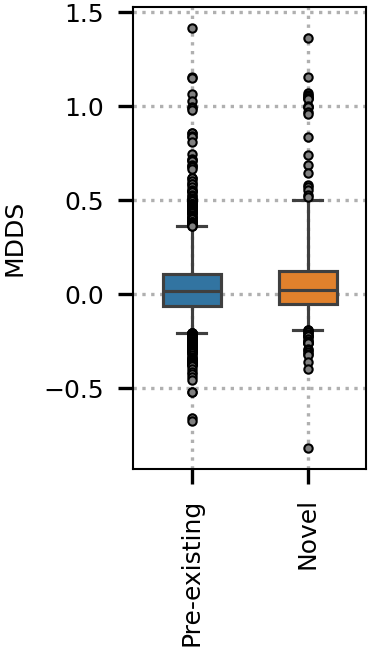

In [23]:
plt.figure(figsize = (1,2))
sns.boxplot(dep_fpr_analysis_nodup,
            x = 'novel', y = 'MDDS', hue = 'novel',
            whis = (5,95), 
            fliersize = 2, 
            flierprops = {'markerfacecolor':'gray','markeredgecolor':'k', 'markeredgewidth':0.5}, 
            width = 0.5, linewidth=0.75, legend=None,
            palette='tab10')
plt.grid(zorder= 0, ls = ':')
plt.xticks(labels = ['Pre-existing','Novel'], ticks = [0,1], fontsize = 6)
plt.xlabel(None)
plt.tick_params('x', rotation = 90)
plt.tick_params(labelsize = 6)
plt.savefig('Figures/Manuscript/Supplemental_Figure_13/S13A_CCLE_Dependency_Scores_Arch_Novelty.svg')

In [24]:
import scipy.stats as stats

In [25]:
dep_fpr_analysis_nodup.MDDS.le(0.5).sum()/len(dep_fpr_analysis_nodup)

0.971535230984601

In [26]:
dep_fpr_analysis_nodup.MDDS.le(0.5).sum()

2082

In [27]:
dep_fpr_analysis_nodup[['MDDS','novel']].groupby('novel').mean()

,MDDS
novel,
False,0.03725
True,0.07142


In [28]:
stats.mannwhitneyu(dep_fpr_analysis_nodup[dep_fpr_analysis_nodup.novel].MDDS, dep_fpr_analysis_nodup[~dep_fpr_analysis_nodup.novel].MDDS)

MannwhitneyuResult(statistic=388972.0, pvalue=0.1029425625371175)

In [29]:
dep_fpr_analysis.to_csv('Fusion_dependency_results.csv')

In [30]:
dep_fpr_analysis.dansy_impact = pd.Categorical(dep_fpr_analysis.dansy_impact, hue_order)

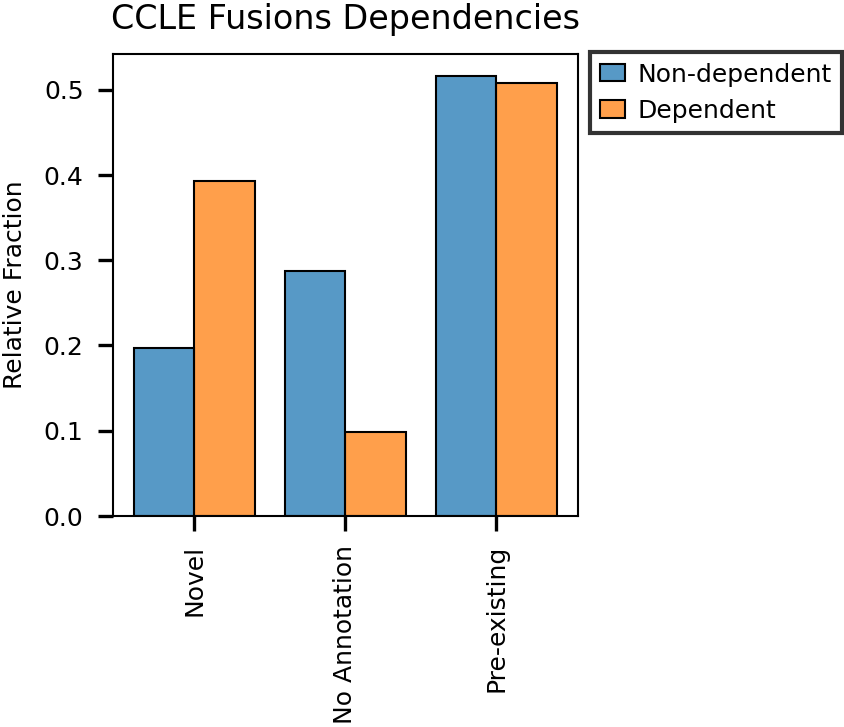

In [31]:
ax = sns.histplot(dep_fpr_analysis[~dep_fpr_analysis.duplication], 
                  x = 'dansy_impact', hue = 'potential_dependence', 
                  multiple='dodge', stat='proportion', 
                  common_norm=False, shrink=0.8,
                  linewidth = 0.5,
                  palette='tab10')
plt.title('CCLE Fusions Dependencies', fontdict={'fontsize':8})
plt.ylabel('Relative Fraction',size = 6)
plt.xlabel(None)
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(2,2)
#sns.move_legend(ax,'upper left',bbox_to_anchor = (1,1), edgecolor = 'k')

sns.move_legend(ax,labels = ['Non-dependent', 'Dependent'],
                loc = 'upper left', 
           bbox_to_anchor = [1,1.03], 
           title = None, 
           handletextpad = 0.5,handlelength = 1,
           fontsize = 6,
           edgecolor = 'k', fancybox = False)

plt.tick_params(labelsize= 6)
plt.tick_params('x', rotation = 90)
plt.savefig('Figures/Manuscript/Supplemental_Figure_13/13B_Dependency_DANSy_Distribution.svg')